In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [254]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [255]:
df = pd.read_csv("3-customersatisfaction.csv")

In [256]:
df

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365
...,...,...,...
95,95,2.055072,8.686851
96,96,0.864149,2.901486
97,97,-1.586101,0.786207
98,98,1.558528,5.447475


In [257]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [258]:
df

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365
...,...,...
95,2.055072,8.686851
96,0.864149,2.901486
97,-1.586101,0.786207
98,1.558528,5.447475


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


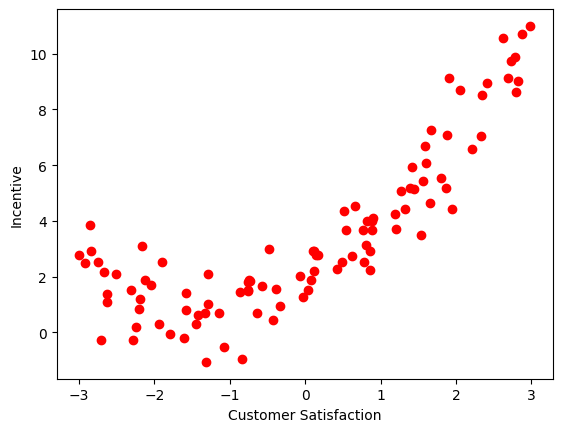

In [260]:
plt.scatter(df["Customer Satisfaction"], df["Incentive"], color="r")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.show()

In [261]:
# dependent - independent features 

X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [262]:
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [263]:
y.head()

0     1.010513
1     2.281043
2     4.415053
3    10.563600
4     0.627365
Name: Incentive, dtype: float64

In [264]:
# train - test split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=15)

In [265]:
# scaler

In [266]:
scaler = StandardScaler()

In [267]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [268]:
regression = LinearRegression()

In [269]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [270]:
## prediction

In [271]:
y_pred = regression.predict(X_test)

In [272]:
y_pred

array([ 4.65663741,  3.71913877,  1.64121789,  6.29646523,  3.46766736,
        5.7580845 ,  4.692485  ,  3.61616231,  5.62448003,  0.13472702,
        4.47909659,  4.8130839 ,  1.58319087,  0.30515983,  5.27634309,
        0.41711005, -0.7385295 , -0.32653914,  3.55906887,  1.19798631])

In [273]:
score = r2_score(y_test, y_pred)

In [274]:
score # Aşırı düşük bir sonuç. Lineer regresyon bunu ölçemez 

0.2705652535622246

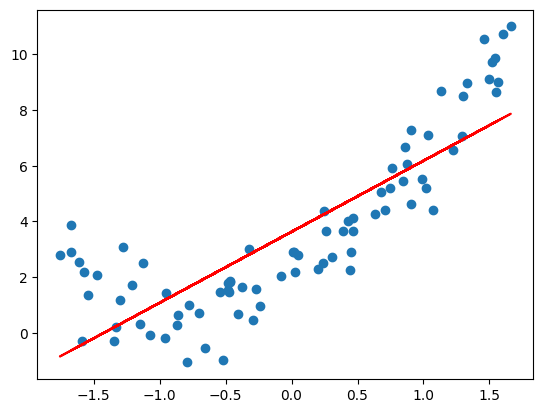

In [275]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color="r")
plt.show()

In [276]:
# Görüldüğü üzere lineer regresyon her zaman doğru açıklamalar ve tahminler yapmıyor!!

In [277]:
# Bu regresyonu polinom haline nasıl getiririz? r2 score'u nasıl artırırız ona bakacağız...

In [278]:
poly = PolynomialFeatures(degree=2, include_bias=True) # include_bias default -> TRUE

In [279]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test) 

In [280]:
X_train_poly

array([[ 1.00000000e+00,  2.47633535e-01,  6.13223675e-02],
       [ 1.00000000e+00,  1.45565669e+00,  2.11893639e+00],
       [ 1.00000000e+00, -5.40182671e-01,  2.91797318e-01],
       [ 1.00000000e+00, -7.00039198e-01,  4.90054879e-01],
       [ 1.00000000e+00,  1.56862116e+00,  2.46057233e+00],
       [ 1.00000000e+00,  9.87568378e-01,  9.75291302e-01],
       [ 1.00000000e+00,  4.48640749e-01,  2.01278522e-01],
       [ 1.00000000e+00,  1.54377517e+00,  2.38324178e+00],
       [ 1.00000000e+00,  1.33219938e+00,  1.77475518e+00],
       [ 1.00000000e+00, -4.80410926e-01,  2.30794658e-01],
       [ 1.00000000e+00,  3.92892957e-01,  1.54364876e-01],
       [ 1.00000000e+00, -6.57456685e-01,  4.32249293e-01],
       [ 1.00000000e+00,  4.42663768e-01,  1.95951211e-01],
       [ 1.00000000e+00, -8.72131603e-01,  7.60613533e-01],
       [ 1.00000000e+00, -1.57257044e+00,  2.47297780e+00],
       [ 1.00000000e+00, -4.70184630e-01,  2.21073587e-01],
       [ 1.00000000e+00, -8.36083500e-02

In [281]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [282]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.7685687698788557


In [283]:
# Görüldüğü gibi tahmin oranımız 0.76 seviyelerine çıktı...

In [284]:
regression.coef_

array([0.        , 2.63871762, 1.54959954])

In [285]:
regression.intercept_

np.float64(2.076676429793281)

<function matplotlib.pyplot.show(close=None, block=None)>

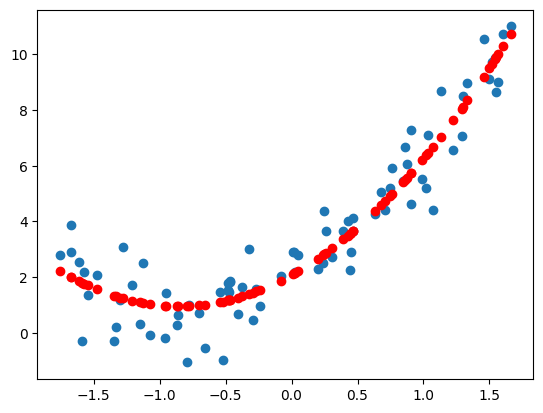

In [286]:
plt.scatter(X_train,y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")
plt.show

In [287]:
# Best fit line doğrumuz daha düzgün oldu <----

In [288]:
# Degree'yi 3 yapalım bakalım -->

poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [289]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.7573443621401051


In [290]:
# Degree 2 olduğunda daha iyi sonuç aldık!

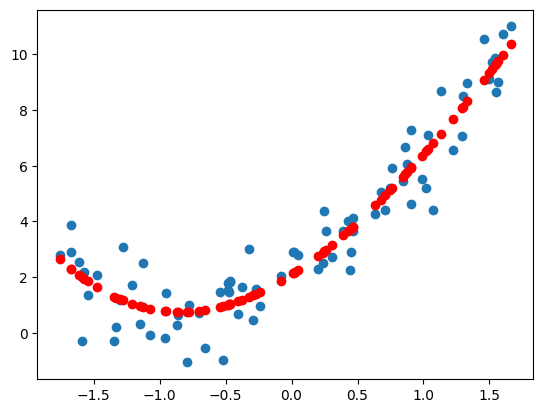

In [291]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")
plt.show()

In [292]:
# new data

In [293]:
new_df = pd.read_csv("3-newdatas.csv")

In [294]:
new_df.head() # sadece customer satisfiction kolonu var biz bu değerlere göre Incentive tahminleri yapacağız.

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397


In [295]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       200 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [296]:
new_df.rename(columns={"0": "Customer Satisfaction"}, inplace=True) # Kolon ismini değiştirdik

In [297]:
new_df

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [298]:
X_new = new_df[["Customer Satisfaction"]]

In [299]:
X_new = scaler.transform(X_new)

# Altın kural: Yeni gelen veriye asla yeniden fit etme; eğitimde öğrendiğin scaler/feature mapping’i aynen uygula.

In [300]:
X_new_poly = poly.transform(X_new)

In [301]:
y_new = regression.predict(X_new_poly)

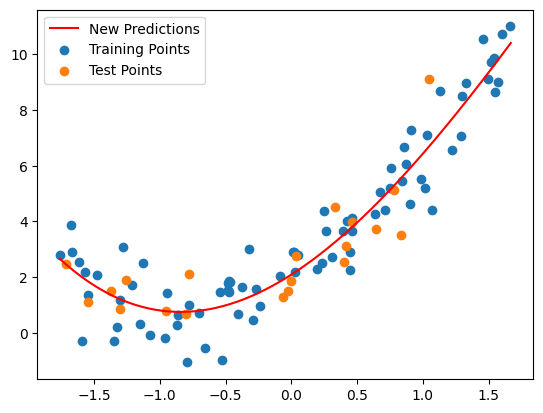

In [302]:
plt.plot(X_new,y_new, "r", label="New Predictions")
plt.scatter(X_train,y_train,  label="Training Points")
plt.scatter(X_test, y_test, label="Test Points")
plt.legend()
plt.show()

In [303]:
# pipeline -> Bir fonksiyonla birlikte ard arda 8 9 tane degree için denemek.

# Pipeline: “Önce scale, sonra poly, en son linear regression” gibi adımları tek bir model gibi zincirler.

In [317]:
def poly_regression(degree):
    
    scaler = StandardScaler()
    poly_features = PolynomialFeatures(degree=degree)
    lin_reg = LinearRegression()
    
    pipeline = Pipeline([
        ("standard_scaler", scaler),
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print("R2 score: ", score)

    y_pred_new = pipeline.predict(X_new)
    plt.plot(X_new, y_pred_new, "r", label="New Predictions")
    plt.scatter(X_train, y_train, label="Training Points")
    plt.scatter(X_test, y_test, label="Test Points")
    plt.legend()
    plt.show()

R2 score:  0.6702608818716445


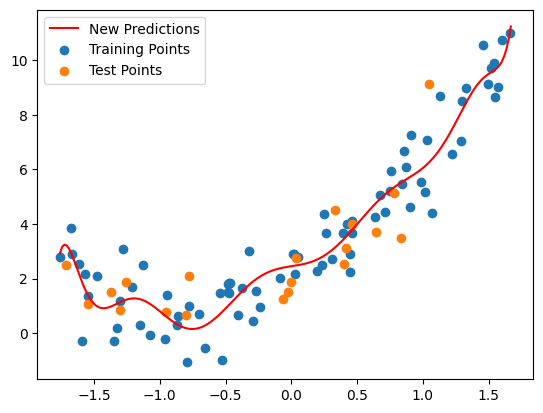

In [322]:
poly_regression(12)

In [324]:
# X_train → StandardScaler → PolynomialFeatures → LinearRegression → Eğitilmiş Model
#                ↓                    ↓                   ↓
#           Normalize           X, X², X³...      Katsayıları bul
#          (μ=0, σ=1)         özellikleri        (w₀, w₁, w₂...)

R2 score:  0.2705652535622246


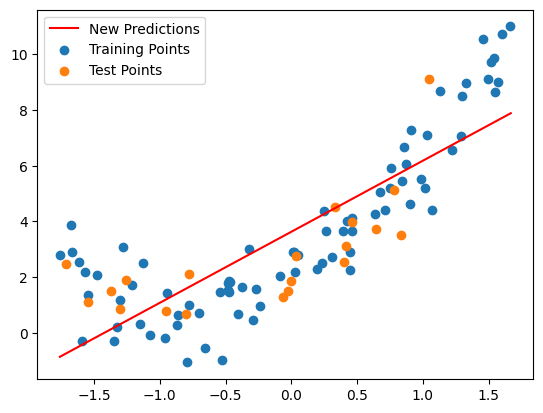

R2 score:  0.7685687698788558


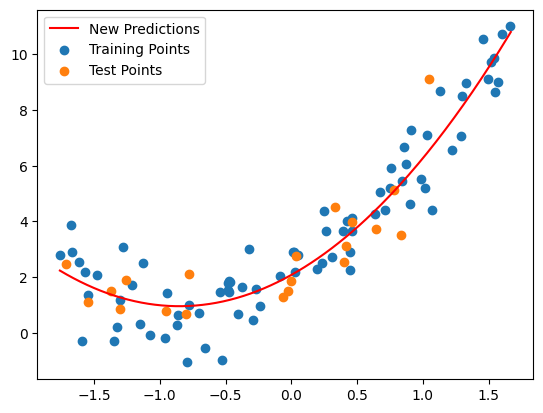

R2 score:  0.7573443621401048


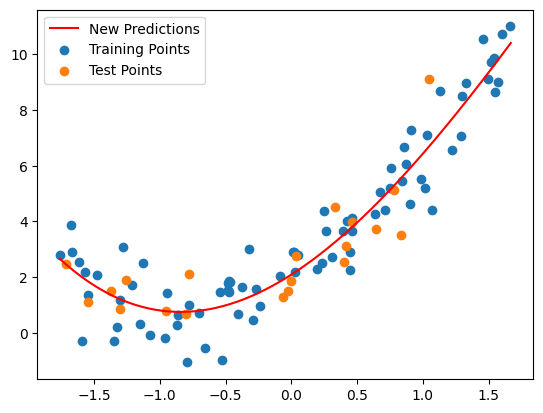

R2 score:  0.7355034443260413


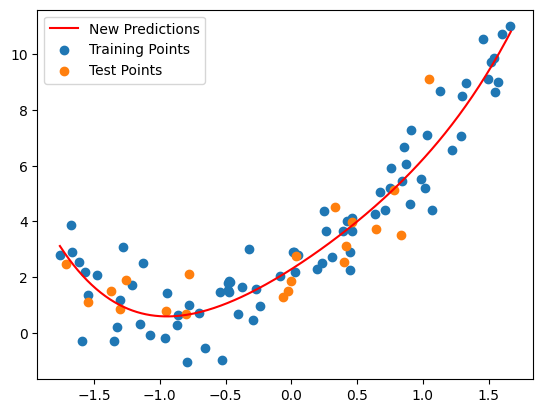

R2 score:  0.7351244165095402


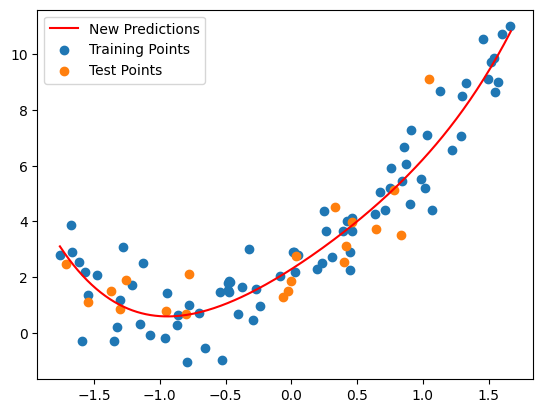

R2 score:  0.734359048213343


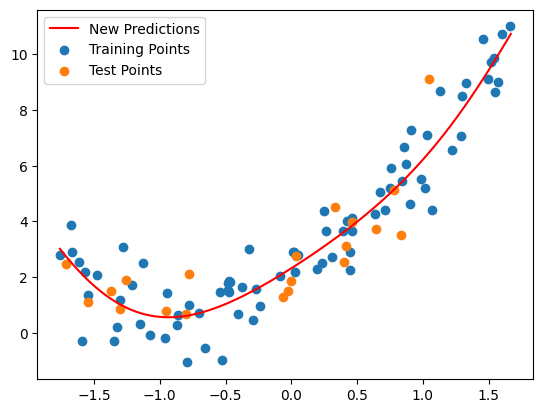

R2 score:  0.7347819263549451


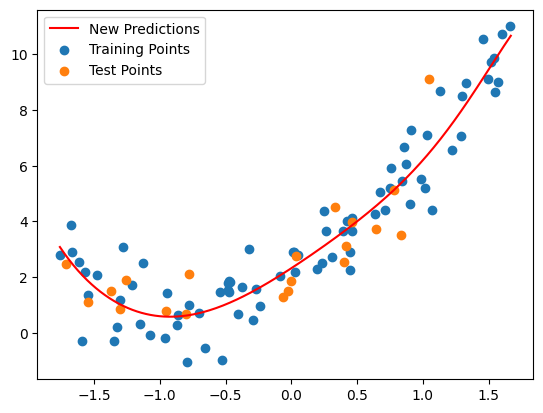

R2 score:  0.7411422099998375


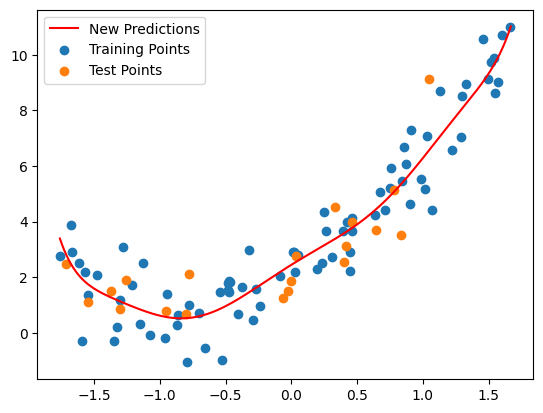

R2 score:  0.7310763879815918


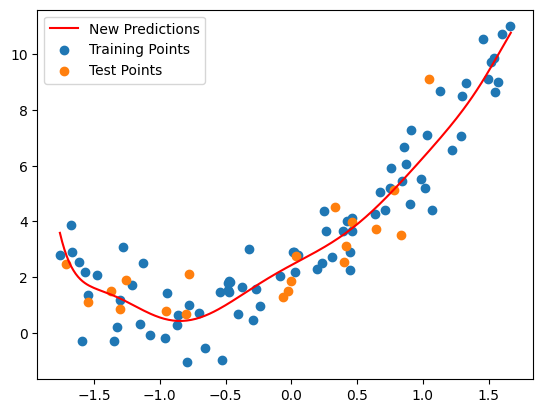

R2 score:  0.728057862123283


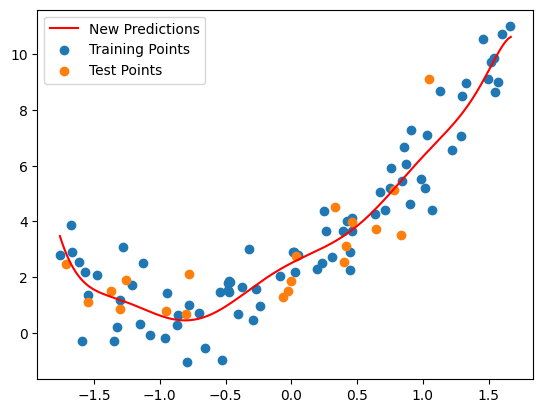

In [316]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(degree)  # Grafikler gittikçe overfitting olayını gözle görebiliyoruz!!